In [58]:
import math

import matplotlib.pyplot as plt
import os

import keras
from keras import *
from keras.datasets import mnist
from keras.layers import *
from keras.activations import *
from keras.models import load_model, save_model
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt

from nnom import *

In [59]:
model_name = 'regression_simple_trained_model.h5'
nsamples = 1000
val_ratio = 0.2
test_ratio = 0.2
x_values = np.random.uniform(low=0, high=(2 * math.pi), size=nsamples)
y_values = np.sin(x_values)

In [60]:
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

<function matplotlib.pyplot.show(close=None, block=None)>

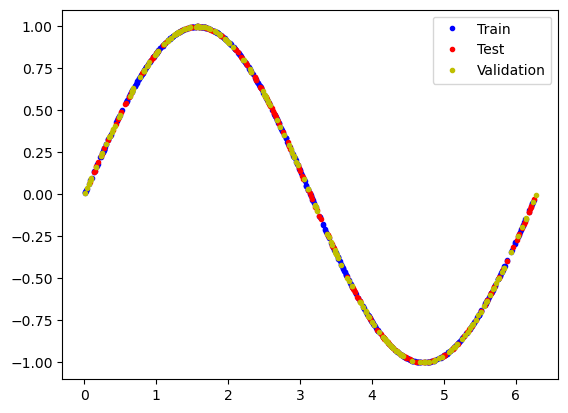

In [61]:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validation")
plt.legend()
plt.show

In [87]:
model = keras.Sequential()
model.add(layers.Dense(18, activation='relu', name='layer1', input_shape=(1,)))
model.add(layers.Dense(12, activation='relu', name='layer2'))
model.add(layers.Dense(10, activation='relu', name='layer3'))
model.add(layers.Dense(10, activation='relu', name='layer4'))
model.add(layers.Dense(1))

model.summary()

Model: "sequential_20"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer1 (Dense)               (None, 18)                36        
_________________________________________________________________
layer2 (Dense)               (None, 12)                228       
_________________________________________________________________
layer3 (Dense)               (None, 10)                130       
_________________________________________________________________
layer4 (Dense)               (None, 10)                110       
_________________________________________________________________
dense_19 (Dense)             (None, 1)                 11        
Total params: 515
Trainable params: 515
Non-trainable params: 0
_________________________________________________________________


Epoch 1/500
6/6 [==============================] - 0s 26ms/step - loss: 0.6047 - mae: 0.6047 - val_loss: 0.5788 - val_mae: 0.5788
Epoch 2/500
6/6 [==============================] - 0s 11ms/step - loss: 0.5695 - mae: 0.5695 - val_loss: 0.5492 - val_mae: 0.5492
Epoch 3/500
6/6 [==============================] - 0s 11ms/step - loss: 0.5514 - mae: 0.5514 - val_loss: 0.5340 - val_mae: 0.5340
Epoch 4/500
6/6 [==============================] - 0s 10ms/step - loss: 0.5384 - mae: 0.5384 - val_loss: 0.5232 - val_mae: 0.5232
Epoch 5/500
6/6 [==============================] - 0s 11ms/step - loss: 0.5272 - mae: 0.5272 - val_loss: 0.5112 - val_mae: 0.5112
Epoch 6/500
6/6 [==============================] - 0s 11ms/step - loss: 0.5189 - mae: 0.5189 - val_loss: 0.5038 - val_mae: 0.5038
Epoch 7/500
6/6 [==============================] - 0s 10ms/step - loss: 0.5081 - mae: 0.5081 - val_loss: 0.4939 - val_mae: 0.4939
Epoch 8/500
6/6 [==============================] - 0s 10ms/step - loss: 0.4993 - mae: 0.49

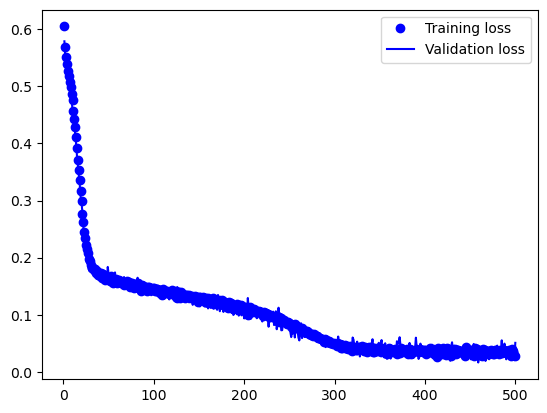

In [88]:
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.show()

In [89]:
print(x_test.shape)

(200,)


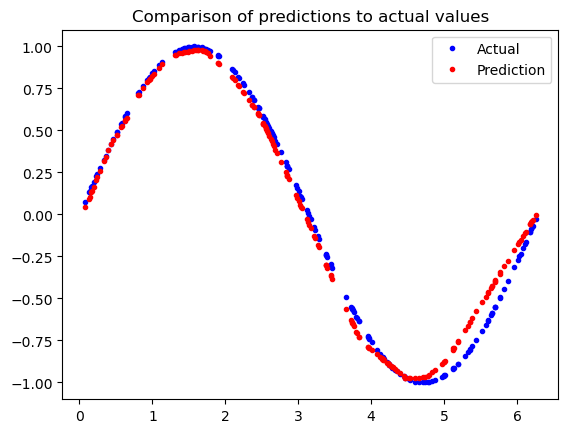

In [90]:
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparison of predictions to actual values")
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Prediction')
plt.legend()
plt.show()

In [ ]:
# test data to c file 
